In [1]:
import pandas as pd
import sqlite3

# CSV load karo
df_train = pd.read_csv('../data/churn-bigml-80.csv')
df_test  = pd.read_csv('../data/churn-bigml-20.csv')

# Dono combine karo
df = pd.concat([df_train, df_test], ignore_index=True)

# Column names clean karo (spaces hata do)
df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()

# Churn column ko 0/1 mein convert karo
df['churn'] = df['churn'].astype(int)

# SQLite database bana aur data daal do
conn = sqlite3.connect('../database/churn.db')
df.to_sql('customers', conn, if_exists='replace', index=False)

print(f"Total rows loaded: {len(df)}")
print("Database ready!")
conn.close()

Total rows loaded: 3333
Database ready!


In [3]:
import sqlite3
import pandas as pd

def run_query(query):
    conn = sqlite3.connect('../database/churn.db')
    result = pd.read_sql_query(query, conn)
    conn.close()
    return result

In [4]:
run_query("""
    SELECT 
        COUNT(*) as total_customers,
        SUM(churn) as churned,
        ROUND(SUM(churn) * 100.0 / COUNT(*), 2) as churn_rate_percent
    FROM customers
""")

,total_customers,churned,churn_rate_percent
0,3333,483,14.49


In [5]:
run_query("""
    SELECT 
        state,
        COUNT(*) as total,
        SUM(churn) as churned,
        ROUND(SUM(churn) * 100.0 / COUNT(*), 2) as churn_rate
    FROM customers
    GROUP BY state
    ORDER BY churn_rate DESC
    LIMIT 10
""")

,state,total,churned,churn_rate
0,NJ,68,18,26.47
1,CA,34,9,26.47
2,TX,72,18,25.00
3,MD,70,17,24.29
4,SC,60,14,23.33
5,MI,73,16,21.92
6,MS,65,14,21.54
7,WA,66,14,21.21
8,NV,66,14,21.21
9,ME,62,13,20.97


In [6]:
run_query("""
    SELECT 
        international_plan,
        COUNT(*) as total,
        SUM(churn) as churned,
        ROUND(SUM(churn) * 100.0 / COUNT(*), 2) as churn_rate
    FROM customers
    GROUP BY international_plan
""")

,international_plan,total,churned,churn_rate
0,No,3010,346,11.50
1,Yes,323,137,42.41


In [7]:
run_query("""
    SELECT 
        customer_service_calls,
        COUNT(*) as total_customers,
        SUM(churn) as churned,
        ROUND(SUM(churn) * 100.0 / COUNT(*), 2) as churn_rate
    FROM customers
    GROUP BY customer_service_calls
    ORDER BY customer_service_calls
""")

,customer_service_calls,total_customers,churned,churn_rate
0,0,697,92,13.20
1,1,1181,122,10.33
2,2,759,87,11.46
3,3,429,44,10.26
4,4,166,76,45.78
5,5,66,40,60.61
6,6,22,14,63.64
7,7,9,5,55.56
8,8,2,1,50.00
9,9,2,2,100.00


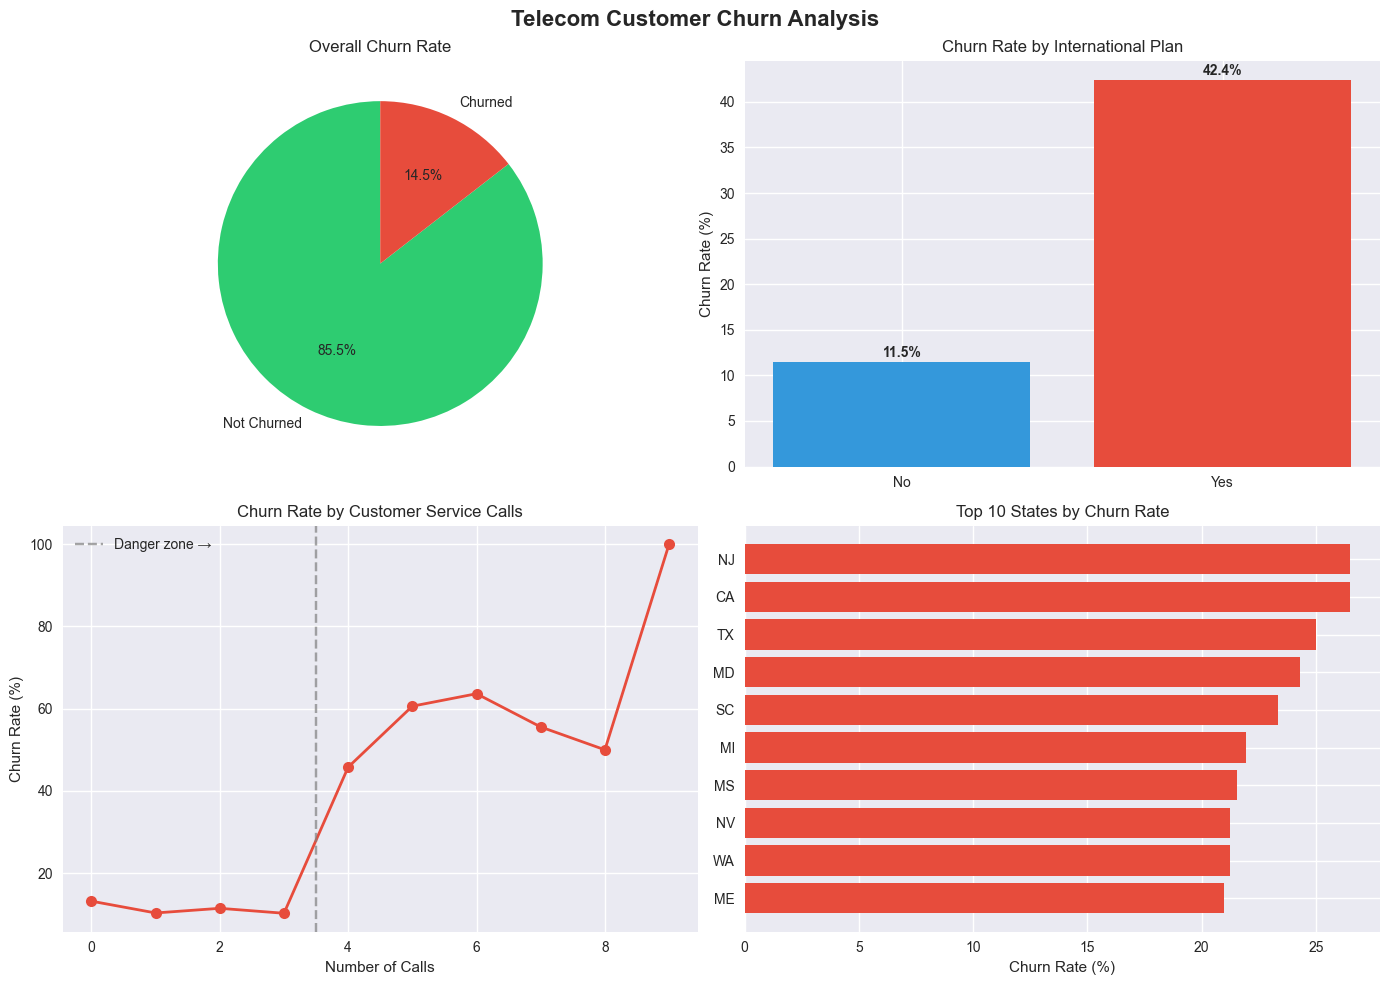

Plot saved!


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import pandas as pd

# Data load 
conn = sqlite3.connect('../database/churn.db')
df = pd.read_sql_query("SELECT * FROM customers", conn)
conn.close()

# Plot style 
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Telecom Customer Churn Analysis', fontsize=16, fontweight='bold')

# Plot 1 — Churn Distribution
churn_counts = df['churn'].value_counts()
axes[0,0].pie(churn_counts, labels=['Not Churned', 'Churned'], 
              autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'], startangle=90)
axes[0,0].set_title('Overall Churn Rate')

# Plot 2 — International Plan vs Churn
intl_churn = df.groupby('international_plan')['churn'].mean() * 100
axes[0,1].bar(intl_churn.index, intl_churn.values, color=['#3498db','#e74c3c'])
axes[0,1].set_title('Churn Rate by International Plan')
axes[0,1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(intl_churn.values):
    axes[0,1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Plot 3 — Customer Service Calls vs Churn
cs_churn = df.groupby('customer_service_calls')['churn'].mean() * 100
axes[1,0].plot(cs_churn.index, cs_churn.values, marker='o', 
               color='#e74c3c', linewidth=2, markersize=8)
axes[1,0].axvline(x=3.5, color='gray', linestyle='--', alpha=0.7, label='Danger zone →')
axes[1,0].set_title('Churn Rate by Customer Service Calls')
axes[1,0].set_xlabel('Number of Calls')
axes[1,0].set_ylabel('Churn Rate (%)')
axes[1,0].legend()

# Plot 4 — Top 10 States by Churn Rate
state_churn = df.groupby('state')['churn'].mean().sort_values(ascending=False).head(10) * 100
axes[1,1].barh(state_churn.index[::-1], state_churn.values[::-1], color='#e74c3c')
axes[1,1].set_title('Top 10 States by Churn Rate')
axes[1,1].set_xlabel('Churn Rate (%)')

plt.tight_layout()
plt.savefig('../dashboard/churn_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

# Categorical columns encode 
df_model = df.copy()
le = LabelEncoder()
for col in ['state', 'international_plan', 'voice_mail_plan']:
    df_model[col] = le.fit_transform(df_model[col])

# Features and target defferentiate 
X = df_model.drop('churn', axis=1)
y = df_model['churn']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model training 
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
model.fit(X_train, y_train)

# Results
y_pred = model.predict(X_test)
print("=== Model Performance ===")
print(classification_report(y_test, y_pred))

C:\Users\asder\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== Model Performance ===
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       574
           1       0.96      0.70      0.81        93

    accuracy                           0.95       667
   macro avg       0.95      0.85      0.89       667
weighted avg       0.95      0.95      0.95       667



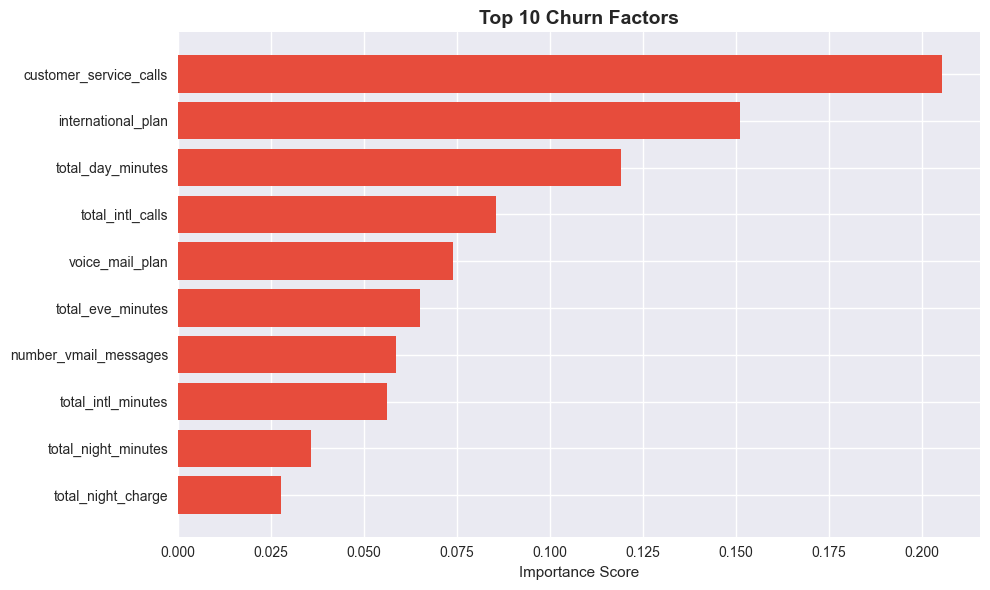

Feature importance plot saved!


In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Feature importance directly from XGBoost
importance = model.feature_importances_
feature_names = X_test.columns.tolist()

# Sort 
indices = np.argsort(importance)[::-1][:10]  # top 10
top_features = [feature_names[i] for i in indices]
top_importance = [importance[i] for i in indices]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(top_features[::-1], top_importance[::-1], color='#e74c3c')
plt.title('Top 10 Churn Factors', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../dashboard/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance plot saved!")

In [2]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('../database/churn.db')
df = pd.read_sql_query("SELECT * FROM customers", conn)
conn.close()

# Summary table 1 — State wise churn
state_summary = df.groupby('state').agg(
    total_customers=('churn', 'count'),
    churned=('churn', 'sum'),
    avg_day_minutes=('total_day_minutes', 'mean'),
    avg_service_calls=('customer_service_calls', 'mean')
).reset_index()
state_summary['churn_rate'] = (state_summary['churned'] / state_summary['total_customers'] * 100).round(2)
state_summary.to_csv('../dashboard/state_summary.csv', index=False)

# Summary table 2 — International plan churn
intl_summary = df.groupby('international_plan').agg(
    total=('churn','count'),
    churned=('churn','sum'),
    avg_day_charge=('total_day_charge','mean')
).reset_index()
intl_summary['churn_rate'] = (intl_summary['churned'] / intl_summary['total'] * 100).round(2)
intl_summary.to_csv('../dashboard/intl_summary.csv', index=False)

# Summary table 3 — Service calls churn
calls_summary = df.groupby('customer_service_calls').agg(
    total=('churn','count'),
    churned=('churn','sum')
).reset_index()
calls_summary['churn_rate'] = (calls_summary['churned'] / calls_summary['total'] * 100).round(2)
calls_summary['risk_level'] = calls_summary['customer_service_calls'].apply(
    lambda x: 'High Risk' if x >= 4 else 'Medium Risk' if x >= 2 else 'Low Risk'
)
calls_summary.to_csv('../dashboard/calls_summary.csv', index=False)

# Full dataset with risk flag for Power BI
df['risk_flag'] = df['customer_service_calls'].apply(
    lambda x: 'High Risk' if x >= 4 else 'Medium Risk' if x >= 2 else 'Low Risk'
)
df['predicted_churn'] = model.predict(
    df.drop('churn', axis=1).apply(pd.to_numeric, errors='coerce').fillna(0)
)
df.to_csv('../dashboard/full_data_powerbi.csv', index=False)

print("Sab CSV files save ho gayi dashboard folder mein!")
print("Files:")
print("- state_summary.csv")
print("- intl_summary.csv") 
print("- calls_summary.csv")
print("- full_data_powerbi.csv")

NameError: name 'model' is not defined